In [1]:
!pip install tf-levenberg-marquardt 

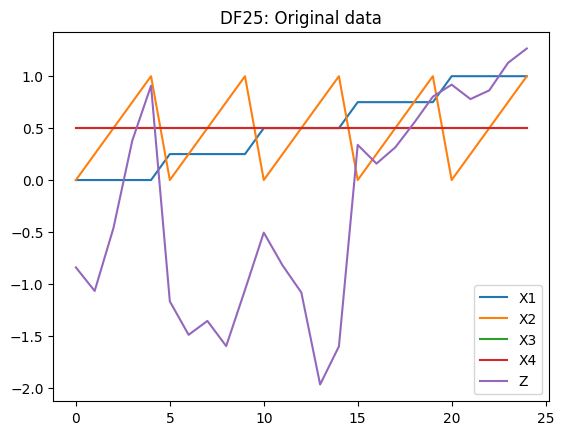

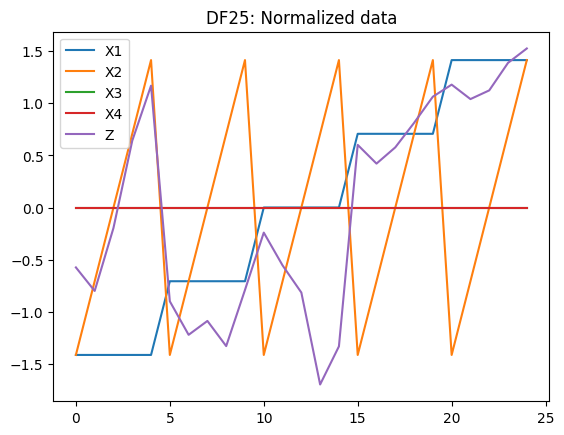

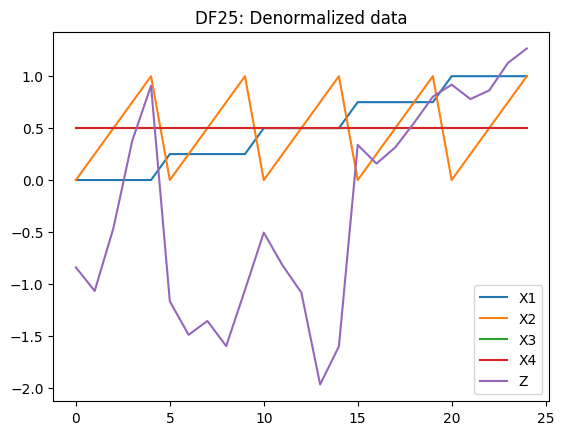

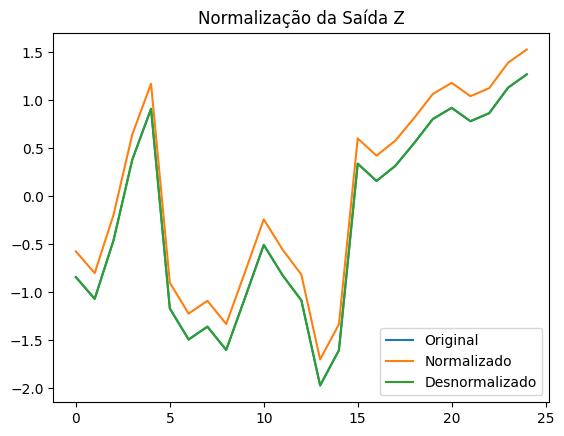

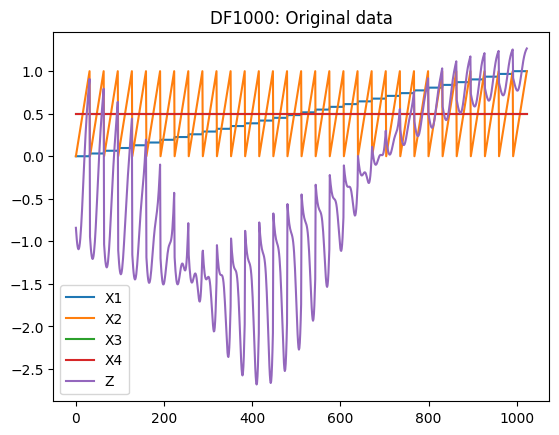

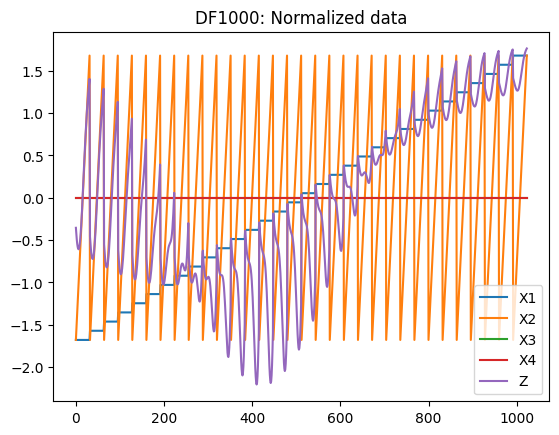

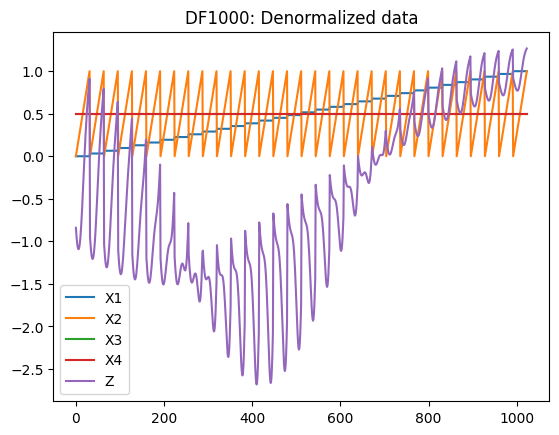

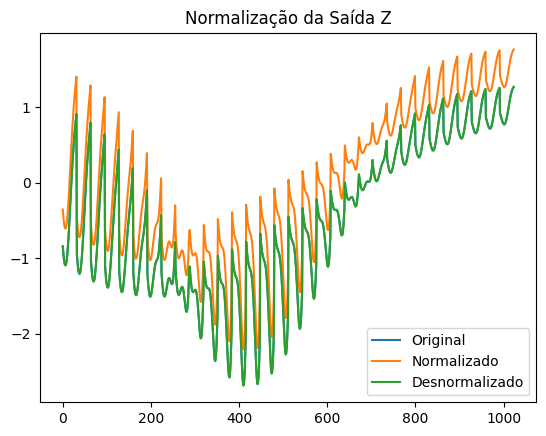

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Escaladores globais
scaler = StandardScaler()
out_scaler = StandardScaler()

# Função Hartmann4
def function(x):
    alpha = np.array([1.0, 1.2, 3.0, 3.2])

    A = np.array([
        [10,   3, 17, 3.5],
        [0.05, 10, 17, 0.1],
        [3, 3.5, 1.7, 10],
        [17,   8, 0.05, 10]
    ])

    P = 1e-4 * np.array([
        [1312, 1696, 5569, 124],
        [2329, 4135, 8307, 3736],
        [2348, 1451, 3522, 2883],
        [4047, 8828, 8732, 5743]
    ])

    x = np.asarray(x)
    if np.any((x < 0) | (x > 1)):
        raise ValueError("Todos os valores de x devem estar no intervalo [0, 1].")

    diff = x - P
    exp_term = np.exp(-np.sum(A * diff**2, axis=1))
    z = (1.1 - np.dot(alpha, exp_term)) / 0.839

    x1, x2, x3, x4 = x
    return z, x1, x2, x3, x4

# Criação do DataFrame com grid 2D (x1, x2), fixando x3, x4
def create_dataframe(grid, x3=0.5, x4=0.5):
    x_vals = np.linspace(0, 1, grid)
    data = []

    for x1 in x_vals:
        for x2 in x_vals:
            z, x1, x2, x3_val, x4_val = function([x1, x2, x3, x4])
            data.append([x1, x2, x3_val, x4_val, z])

    df = pd.DataFrame(data, columns=["X1", "X2", "X3", "X4", "Z"])
    return df

# Visualização da normalização
def show_norm(df, label="function", plot=False):
    df_norm = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
    df_denorm = pd.DataFrame(scaler.inverse_transform(df_norm), columns=df_norm.columns)

    if plot:
        df.plot(title=f"{label}: Original data")
        df_norm.plot(title=f"{label}: Normalized data")
        df_denorm.plot(title=f"{label}: Denormalized data")
        plt.show()
    return df_norm

# Visualizar normalização da saída Z
def test_out_scaler(df):
    out = df["Z"].values.reshape(-1, 1)
    plt.figure()
    plt.plot(out, label='Original')
    out_scaler.fit(out)
    norm = out_scaler.transform(out)
    plt.plot(norm, label='Normalizado')
    plt.plot(out_scaler.inverse_transform(norm), label='Desnormalizado')
    plt.title("Normalização da Saída Z")
    plt.legend()
    plt.show()

# Execução dos testes
df_25 = create_dataframe(grid=5)
df_25_norm = show_norm(df_25, label="DF25", plot=True)
test_out_scaler(df_25)

df_1000 = create_dataframe(grid=32)
df_1000_norm = show_norm(df_1000, label="DF1000", plot=True)
test_out_scaler(df_1000)




In [3]:
def split_df(df):
    _input = np.vstack([df['X1'], df['X2'], df['X3'], df['X4']]).T
    _output = np.array(df['Z'])
    return (_input, _output)


In [4]:
import tensorflow as tf
import numpy as np
from keras import regularizers
from keras import initializers
import tf_levenberg_marquardt as lm

# layers, neurons
class ShuffleArchitecture:
    def __init__(self, input_size, hidden_sizes, output_size, act_h, act_o, param_reg):
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.output_size = output_size
        self.act_h = act_h
        self.act_o = act_o
        self.regularizer = regularizers.L2(param_reg)
        self.initializer = initializers.RandomUniform(minval=-0.5, maxval=0.5, seed=np.random.randint(1, 10000))

    def compute_k(self):
        total_parameters = 0
        for layer in self.model.layers:
            weights = layer.get_weights()
            if len(weights) > 0:  
                for w in weights:
                    total_parameters += np.prod(w.shape)
        return total_parameters
        
    def set_architecture(self):
        self.model = tf.keras.Sequential()
        self.model.add(tf.keras.layers.Dense(self.hidden_sizes[0],
                        input_shape=(self.input_size,),
                        activation=self.act_h,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,                        
                        ))  # input layer

        for size in self.hidden_sizes[1:]:  # hidden layers
            self.model.add(tf.keras.layers.Dense(size,
                            activation=self.act_h,
                            kernel_regularizer=self.regularizer,
                            kernel_initializer=self.initializer,  
                        ))

        self.model.add(tf.keras.layers.Dense(self.output_size,
                        activation=self.act_o,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,  
                        ))  # output layer

    def create_model(self, _learning_rate):
        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=_learning_rate),
            loss=tf.keras.losses.MeanSquaredError(),
        )
        self.lm_model = lm.model.ModelWrapper(
            tf.keras.models.clone_model(self.model)
        )
        self.lm_model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=_learning_rate),
            loss=lm.loss.MeanSquaredError()
        )
        return self.lm_model


2025-06-24 16:17:54.650266: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-24 16:17:55.522814: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-24 16:17:55.523005: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-24 16:17:55.655029: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-24 16:17:56.334395: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-24 16:17:56.335542: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [5]:
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 

class TrainWithSmallDataset:
    def __init__(self, batch_size=1000):
        self.batch_size = batch_size
        self.betters = []
        self.k = 0

    def create_dataset(self, input, output):
      input = tf.cast(input, tf.float32)  # Mantém shape (N, 4)
      output = tf.expand_dims(tf.cast(output, tf.float32), axis=-1)  # Output vira (N, 1)
      dataset = tf.data.Dataset.from_tensor_slices((input, output))
      dataset = dataset.shuffle(len(input))
      dataset = dataset.batch(self.batch_size).cache()
      dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
      return (dataset, input, output)

    def split_dataset(self, input, output, sup_input, sup_output):
      input_train, input_vt, output_train, output_vt = train_test_split(input, output, test_size=0.3, shuffle = True)
      input_val, input_test, output_val, output_test = train_test_split(input_vt, output_vt, test_size=0.5, shuffle = True)

      self.train_dataset, self.train_input, self.train_output = self.create_dataset(input_train, output_train)
      self.val_dataset, self.val_input, self.val_output = self.create_dataset(input_val, output_val)
      self.test_dataset, self.test_input, self.test_output = self.create_dataset(input_test, output_test)
      self.vt_dataset, self.vt_input, self.vt_output = self.create_dataset(input_vt, output_vt)
      self.sup_dataset, self.sup_input, self.sup_output = self.create_dataset(sup_input, sup_output)
      self.dataset, self.input, self.output = self.create_dataset(input, output)

      self._data = (input, output)
      self._train = (input_train, output_train)
      self._vt = (input_vt, output_vt)
      self._val = (input_val, output_val)
      self._test = (input_test, output_test)
      self._sup = (sup_input, sup_output)
 
    def train_using_lm(self, train_dataset, epochs=1000):
      early_stopping_monitor = EarlyStopping(monitor='val_loss',
                                              patience=6,
                                              restore_best_weights=True)

      self.results = self.lm_model.fit(train_dataset,
                                            epochs=epochs,
                                            validation_data=self.val_dataset,
                                            callbacks=[early_stopping_monitor],
                                            verbose=0)
      print ("Stopped at epoch: ", early_stopping_monitor.stopped_epoch)
    
    def get_new_metrics(self, orig, pred, r2, mse):
      n = len(orig) # N: quantidade de saidas
      k = self.k
      waste = (orig.flatten() - pred.flatten())

      mape = mean_absolute_percentage_error(orig, pred)  
      r2_adj = 1 - (((n - 1)/(n - k - 1)) * (1 - r2))
      rsd = np.sqrt(np.sum(waste ** 2) / (n - 2))
      rmse = root_mean_squared_error(orig, pred)          
      aic = (-2 * np.log(mse)) + (2 * k)
      bic = (-2 * np.log(mse)) + (k * np.log(n))
      return (mape, r2_adj, rsd, rmse, aic, bic)
      

    def get_metrics(self):
          # Calculando a saida com os dados normalizados
          pred = self.lm_model.predict(self.input).flatten()
          test_pred = self.lm_model.predict(self.test_input).flatten()
          val_pred = self.lm_model.predict(self.val_input).flatten()
          vt_pred = self.lm_model.predict(self.vt_input).flatten()
          sup_pred = self.lm_model.predict(self.sup_input).flatten()

          # Calculando as metricas com a saida desnormalizada
          pred_denorm = out_scaler.inverse_transform(pred.reshape(-1, 1))
          test_pred_denorm = out_scaler.inverse_transform(test_pred.reshape(-1, 1))
          val_pred_denorm = out_scaler.inverse_transform(val_pred.reshape(-1, 1))
          vt_pred_denorm = out_scaler.inverse_transform(vt_pred.reshape(-1, 1))
          sup_pred_denorm = out_scaler.inverse_transform(sup_pred.reshape(-1, 1))

          out_denorm = out_scaler.inverse_transform(self._data[1].reshape(-1, 1))
          test_denorm = out_scaler.inverse_transform(self._test[1].reshape(-1, 1))
          val_denorm = out_scaler.inverse_transform(self._val[1].reshape(-1, 1))
          vt_denorm = out_scaler.inverse_transform(self._vt[1].reshape(-1, 1))    
          sup_denorm = out_scaler.inverse_transform(self._sup[1].reshape(-1, 1))

          r2 = r2_score(out_denorm, pred_denorm)
          r2_test = r2_score(test_denorm, test_pred_denorm)
          r2_val = r2_score(val_denorm, val_pred_denorm)
          r2_vt = r2_score(vt_denorm,  vt_pred_denorm)
          r2_sup = r2_score(sup_denorm,  sup_pred_denorm)

          mse = mean_squared_error(out_denorm, pred_denorm)
          mse_test = mean_squared_error(test_denorm, test_pred_denorm)
          mse_val = mean_squared_error(val_denorm, val_pred_denorm)
          mse_vt = mean_squared_error(vt_denorm,  vt_pred_denorm)
          mse_sup = mean_squared_error(sup_denorm,  sup_pred_denorm)
          
          mape, r2_adj, rsd, rmse, aic, bic = self.get_new_metrics(out_denorm, pred_denorm, r2, mse)
          metrics = {
                          'r2': r2,
                          'r2_sup': r2_sup,
                          'r2_test': r2_test,
                          'r2_val': r2_val,
                          'r2_vt': r2_vt,
                          'mse': mse,
                          'mse_sup': mse_sup,
                          'mse_test': mse_test,
                          'mse_val': mse_val,
                          'mse_vt': mse_vt,
                          'mape': mape,
                          'rmse': rmse,
                          'r2_adj': r2_adj,
                          'rsd': rsd,
                          'aic': aic,
                          'bic': bic
                          }

          return metrics

In [6]:
import pickle
from itertools import product

class Tester:
  def __init__(self, run_times=500, dataset_run_times=10):
    self.run_times = run_times
    self.better_metrics = {}
    self.dataset_run_times = dataset_run_times
    self.input_25, self.output_25 = split_df(df_25_norm)
    self.input_1000, self.output_1000 = split_df(df_1000_norm)
  
  def setArchitecure(self, trainer, _hidden_sizes, _pg, _lr):
    shuffler = ShuffleArchitecture(input_size=4,
                                    hidden_sizes=_hidden_sizes,
                                    output_size=1,
                                    act_h='tanh',
                                    act_o='linear',
                                    param_reg=_pg)
    shuffler.set_architecture()    
    trainer.lm_model = shuffler.create_model(_lr)
    trainer.k = shuffler.compute_k()

  def Train(self, trainer, epochs=1000):
    trainer.train_using_lm(trainer.train_dataset, epochs=epochs)
    return(trainer.get_metrics(), trainer.lm_model)

  def SaveModelWeights(self, model, fileName):
    path = f"content/models/{fileName}.keras"
    open(path,'w').close()
    model.save_weights(path)

  def SaveDataset(self, trainer, fileName):
    path = f"content/dataset/{fileName}.pkl" 
    with open(path, 'wb') as f:
      pickle.dump((trainer._data, trainer._train, trainer._vt, trainer._val, trainer._test), f)
      
  def LoopWeights(self, sort_by, boundarie, trainer, idx):
    better_model = 0
    save = False

    for i in range(self.run_times):
      print (f"+++++++++++ [{idx}] | {i + 1} ++++++++++++++++++")
      metrics, model = self.Train(trainer)
      if (metrics[sort_by] <= boundarie): # should be >= to acsending metrics
        fileName = f"model_{idx}_{better_model}"
        self.SaveModelWeights(model, fileName)
        self.better_metrics[fileName] = metrics
        better_model += 1
        save = True
    return(save)

  def Loop(self, sort_by, boundarie, hidden_sizes, regularizers, learning_rate):
    trainer = TrainWithSmallDataset()

    for count, (hidden_size, reg, lr) in enumerate(product(hidden_sizes, regularizers, learning_rate), start=1):
      header =  f"Hidden Size={hidden_size}, regularizer={reg}, learning_rate={lr}"
      print(f"Testando combinacao{count}: {header}")
      self.setArchitecure(trainer, hidden_size, reg, lr)
      for j in range(self.dataset_run_times):
        trainer.split_dataset(self.input_25, self.output_25, self.input_1000, self.output_1000)
        if (self.LoopWeights(sort_by, boundarie, trainer, f"{count}_{j}") == True):
          self.SaveDataset(trainer, f"dataset_{count}_{j}")
          self.DisplayBetterResults('mse_sup', header, f"{count}_{j}")
        self.better_metrics = {}

  def DisplayBetterResults(self, sort_by, header, dataset=0):
    df = pd.DataFrame.from_dict(self.better_metrics, orient='index')
    df = df.sort_values([sort_by])
    display(df)
    path = f'content/results/metrics_{dataset}'
    df.to_excel(f"{path}.xlsx", index=True)
    print(f"DataFrame salvo em {path}")
    with open(f"{path}.txt", 'w') as arquivo:
      arquivo.write(header)

# Treinando com 25 dados


In [8]:
tester = Tester(run_times=25, dataset_run_times=10)
tester.Loop(sort_by='mse',
            boundarie = 0.02,
            hidden_sizes = [[5], [6], [7], [8], [9], [10], [11], [12], [13], [14]],
            regularizers=[0.5, 0.03],
            learning_rate=[0.1, 0.05])

Testando combinacao1: Hidden Size=[5], regularizer=0.5, learning_rate=0.1
+++++++++++ [1_0] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_0] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_0] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_0] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_0] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_0] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
++++++

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_3_3_0,0.985896,-2.806804,0.900376,0.884980,0.893502,0.013983,3.774194,0.043619,0.040792,0.042206,0.163859,0.118249,1.048355,0.123283,70.539866,108.325017
model_3_3_1,0.989001,-3.838972,0.884155,0.958977,0.917652,0.010905,4.797521,0.050721,0.014549,0.032635,0.150415,0.104426,1.037711,0.108872,71.037100,108.822251
model_3_3_2,0.989475,-4.749772,0.877665,0.974919,0.921200,0.010434,5.700519,0.053563,0.008895,0.031229,0.132217,0.102149,1.036084,0.106498,71.125290,108.910440
model_3_3_3,0.989333,-4.825626,0.871839,0.979592,0.920073,0.010576,5.775723,0.056113,0.007238,0.031676,0.124832,0.102838,1.036573,0.107216,71.098397,108.883548
model_3_3_4,0.988365,-5.267395,0.856026,0.981985,0.912408,0.011535,6.213707,0.063037,0.006389,0.034713,0.117057,0.107402,1.039891,0.111975,70.924687,108.709838
model_3_3_5,0.987966,-5.485212,0.852791,0.978786,0.909190,0.011931,6.429659,0.064453,0.007524,0.035989,0.116929,0.109230,1.041260,0.113880,70.857211,108.642362
model_3_3_6,0.988107,-5.915512,0.861445,0.970506,0.910265,0.011792,6.856272,0.060664,0.010460,0.035562,0.122825,0.108589,1.040777,0.113212,70.880745,108.665895
model_3_3_7,0.987660,-5.987840,0.854171,0.971621,0.906746,0.012235,6.927981,0.063849,0.010065,0.036957,0.119969,0.110611,1.042310,0.115320,70.806953,108.592103
model_3_3_8,0.987355,-6.054710,0.848927,0.972757,0.904358,0.012537,6.994278,0.066145,0.009662,0.037903,0.117438,0.111968,1.043355,0.116735,70.758172,108.543323
model_3_3_9,0.987215,-6.207359,0.849100,0.970081,0.903256,0.012676,7.145619,0.066069,0.010611,0.038340,0.119071,0.112587,1.043835,0.117380,70.736129,108.521279


DataFrame salvo em content/results/metrics_3_3
+++++++++++ [3_4] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [3_4] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [3_4] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [3_4] | 4 ++++++++++++++++++
Stopped at epoch:  42
32/32 [==============================] - 0s 2ms/step
+++++++++++ [3_4] | 5 ++++++++++++++++++
Stopped at epoch:  7
32/32 [==============================] - 0s 4ms/step
+++++++++++ [3_4] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [3_4] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [3_4] | 8 ++++++++++++++++++
Stopped at epoch:  7
32/32 [==============================] - 0s 3ms/step
+++++++++++ [3_4] | 9 ++++++++++

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_3_4_0,0.987859,-6.132736,0.998655,0.991987,0.995928,0.012037,7.071635,0.001461,0.007745,0.004603,0.107856,0.109714,1.041627,0.114385,70.839513,108.624663
model_3_4_2,0.989131,-6.799448,0.990660,0.979333,0.986676,0.010776,7.732636,0.010147,0.019975,0.015061,0.130759,0.103809,1.037266,0.108228,71.060815,108.845966
model_3_4_1,0.988051,-6.848644,0.993852,0.984310,0.990338,0.011847,7.781411,0.006680,0.015164,0.010922,0.115107,0.108843,1.040968,0.113477,70.871401,108.656551


DataFrame salvo em content/results/metrics_3_4
+++++++++++ [3_5] | 1 ++++++++++++++++++
Stopped at epoch:  17
32/32 [==============================] - 0s 3ms/step
+++++++++++ [3_5] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [3_5] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [3_5] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [3_5] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [3_5] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [3_5] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [3_5] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [3_5] | 9 ++++++++++

...

DataFrame salvo em content/results/metrics_40_7
+++++++++++ [40_8] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 1ms/step
+++++++++++ [40_8] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [40_8] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [40_8] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [40_8] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [40_8] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [40_8] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [40_8] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [40_8] | 9 +

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_40_8_0,0.980935,0.907570,0.988511,0.972227,0.987501,0.018902,0.091638,0.004448,0.018725,0.011586,0.190816,0.137483,1.007501,0.143336,177.937016,281.541461
model_40_8_1,0.981879,0.907370,0.987040,0.968021,0.985664,0.017966,0.091837,0.005018,0.021560,0.013289,0.187406,0.134038,1.007130,0.139744,178.038532,281.642977
model_40_8_2,0.982671,0.907101,0.985546,0.963779,0.983809,0.017180,0.092104,0.005596,0.024420,0.015008,0.184170,0.131074,1.006818,0.136654,178.127977,281.732422
model_40_8_3,0.983331,0.906775,0.984041,0.959534,0.981951,0.016526,0.092427,0.006179,0.027282,0.016731,0.181103,0.128554,1.006558,0.134026,178.205640,281.810085
model_40_8_4,0.983875,0.906403,0.982529,0.955315,0.980101,0.015987,0.092795,0.006764,0.030127,0.018445,0.178198,0.126439,1.006344,0.131822,178.271978,281.876423
model_40_8_5,0.984317,0.905994,0.981020,0.951144,0.978269,0.015548,0.093201,0.007348,0.032939,0.020144,0.175449,0.124694,1.006170,0.130002,178.327585,281.932031
model_40_8_6,0.984671,0.905556,0.979518,0.947038,0.976462,0.015198,0.093635,0.007930,0.035707,0.021818,0.172848,0.123281,1.006031,0.128529,178.373159,281.977604
model_40_8_7,0.984946,0.905096,0.978029,0.943015,0.974688,0.014925,0.094091,0.008506,0.038420,0.023463,0.170391,0.122166,1.005923,0.127367,178.409487,282.013932
model_40_8_8,0.985155,0.904620,0.976558,0.939084,0.972951,0.014718,0.094563,0.009076,0.041069,0.025073,0.168069,0.121317,1.005841,0.126482,178.437398,282.041843
model_40_8_9,0.985305,0.904133,0.975108,0.935257,0.971257,0.014569,0.095046,0.009638,0.043650,0.026644,0.165875,0.120702,1.005782,0.125840,178.457738,282.062183


DataFrame salvo em content/results/metrics_40_8
+++++++++++ [40_9] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [40_9] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 6ms/step
+++++++++++ [40_9] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [40_9] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [40_9] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [40_9] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [40_9] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [40_9] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [40_9] | 9 +

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_40_9_24,0.985370,0.919676,0.925805,0.941507,0.934014,0.014505,0.079636,0.060719,0.024500,0.042609,0.160788,0.120436,1.005756,0.125563,178.466542,282.070987
model_40_9_23,0.985576,0.919492,0.927469,0.942705,0.935457,0.014301,0.079818,0.059357,0.023998,0.041677,0.160629,0.119585,1.005675,0.124676,178.494908,282.099353
model_40_9_22,0.985783,0.919290,0.929199,0.943951,0.936958,0.014095,0.080019,0.057941,0.023476,0.040709,0.160462,0.118721,1.005593,0.123775,178.523908,282.128353
model_40_9_21,0.985992,0.919068,0.930996,0.945246,0.938516,0.013888,0.080239,0.056471,0.022934,0.039702,0.160289,0.117848,1.005511,0.122865,178.553449,282.157894
model_40_9_20,0.986200,0.918824,0.932861,0.946589,0.940133,0.013682,0.080481,0.054945,0.022371,0.038658,0.160108,0.116969,1.005429,0.121948,178.583391,282.187836
model_40_9_19,0.986407,0.918556,0.934793,0.947983,0.941810,0.013477,0.080747,0.053363,0.021787,0.037575,0.159919,0.116090,1.005348,0.121032,178.613558,282.218003
model_40_9_18,0.986610,0.918260,0.936795,0.949426,0.943547,0.013275,0.081040,0.051725,0.021183,0.036454,0.159723,0.115217,1.005268,0.120122,178.643747,282.248192
model_40_9_17,0.986809,0.917935,0.938866,0.950920,0.945343,0.013078,0.081362,0.050031,0.020557,0.035294,0.159518,0.114358,1.005190,0.119226,178.673695,282.278140
model_40_9_16,0.987002,0.917578,0.941005,0.952464,0.947199,0.012887,0.081716,0.048280,0.019910,0.034095,0.159307,0.113520,1.005114,0.118353,178.703091,282.307536
model_40_9_15,0.987186,0.917184,0.943211,0.954057,0.949114,0.012705,0.082107,0.046474,0.019243,0.032859,0.159086,0.112715,1.005042,0.117514,178.731569,282.336014


DataFrame salvo em content/results/metrics_40_9
